# Diabetes Classification : Preprocessing & Model Building

**Pipeline Steps:**
1. [Data Cleaning](#1) : fix strings, drop useless columns
2. [Outlier Handling](#2) : clip extreme values to realistic clinical ranges
3. [Transformation Pipeline](#3) : prepare data for algorithms
4. [Model Training](#4) : Logistic Regression, Decision Tree, Random Forest, XGBoost
5. [Hyperparameter Tuning](#5) : Optuna-based optimization



### Import Libraries and Load Data

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import optuna
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import optuna.visualization as vis

/Users/aakritipoudel/Documents/Leapfrog/diabetes-ml-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load and Inspect Data

In [2]:
df = pd.read_csv('../data/raw/dataset.csv')  

# check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   str    
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   str    
dtypes: float64(8), int64(4), str(2)
memory usage: 109.5 KB


In [3]:
df.nunique()

ID           800
No_Pation    961
Gender         3
AGE           50
Urea         110
Cr           113
HbA1c        111
Chol          77
TG            69
HDL           48
LDL           65
VLDL          60
BMI           64
CLASS          5
dtype: int64

Note: The unique values for Gender and Class are 3 and 5 which is unusual so we further look into their values

In [4]:
print(df['CLASS'].unique())
print(df['Gender'].unique())

<StringArray>
['N', 'N ', 'P', 'Y', 'Y ']
Length: 5, dtype: str
<StringArray>
['F', 'M', 'f']
Length: 3, dtype: str



## Data Cleaning <a id='1'></a>

**String Trimming & Case Consistency**

Both CLASS and Gender columns have inconsistent formatting. We strip whitespace and standardize to uppercase.  

In [5]:
df['CLASS'] = df['CLASS'].str.strip()
df['Gender'] = df['Gender'].str.upper()

print(df['CLASS'].unique())
print(df['Gender'].unique())

<StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str
<StringArray>
['F', 'M']
Length: 2, dtype: str


Drop Redundant Columns: We drop ID and No_Pation Column as they as no predictive power

In [6]:
df.drop(columns=['ID','No_Pation'], inplace=True)
df.head(2)

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N


## Outlier Handling <a id='2'></a>

We use **percentile clipping** (5th–95th percentile) rather than removing outliers entirely.  
Because in clinical data, extreme values are often real. A creatinine of 15 is unusual but medically valid


In [7]:
num_cols = ['Urea','Cr','HbA1c','Chol','TG','HDL','LDL','VLDL','BMI','AGE']

for col in num_cols:
    lower_bound = df[col].quantile(0.05)
    upper_bound = df[col].quantile(0.95)

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)


In [8]:
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,N
1,M,33,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,N
3,F,50,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,N
4,M,33,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


### Data Splitting

We split **before** encoding and scaling. This is important as StandardScaler must be fit *only on training data*, then applied to test data. Fitting on all data first would leak test statistics into the training process (data leakage).

We use **stratified splitting** to ensure each split has the same class proportions as the full dataset.

In [9]:
X = df.drop(columns=['CLASS'])  
y = df['CLASS']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class counts: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Test  class counts: {pd.Series(y_test).value_counts().to_dict()}')


Train: (800, 11), Test: (200, 11)
Train class counts: {'Y': 675, 'N': 82, 'P': 43}
Test  class counts: {'Y': 169, 'N': 21, 'P': 10}


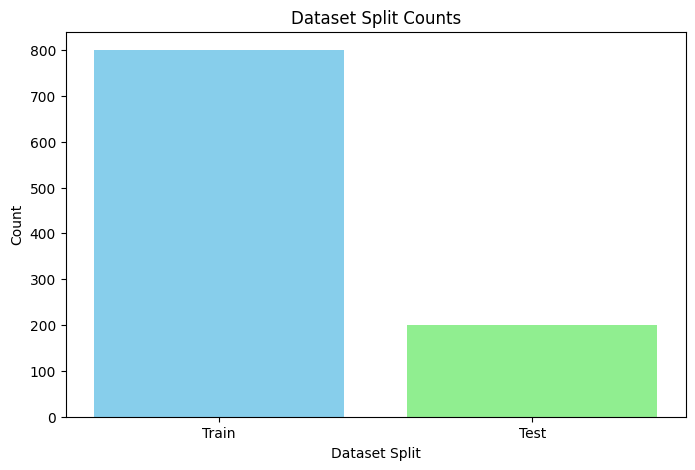

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(['Train','Test'], [len(X_train), len(X_test)], color=['skyblue','lightgreen'])
plt.xlabel('Dataset Split')
plt.ylabel('Count')
plt.title('Dataset Split Counts')
plt.savefig('../outputs/classification/data_split.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Encoding

- **Target (CLASS)**: `LabelEncoder` N=0, P=1, Y=2  
- **Gender**: `OrdinalEncoder`  F=0, M=1 
- **Numerical features**: `StandardScaler` zero mean, unit variance

These go inside a `ColumnTransformer` so we can apply different transforms to different column types cleanly.

In [12]:
le = LabelEncoder()

y_train_processed = le.fit_transform(y_train)
y_test_processed = le.transform(y_test)

## Transformation Pipeline <a id='3'></a>

We build a `ColumnTransformer` that handles numerical and categorical columns separately, then wrap everything in `ImbPipeline` (from imbalanced-learn) so SMOTE runs inside cross-validation folds , not on the whole dataset.


In [13]:
num_cols = ['Urea','Cr','HbA1c','Chol','TG','HDL','LDL','VLDL','BMI','AGE']
cat_cols = ['Gender']

transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(), cat_cols)
    ])


## Model Training <a id='4'></a>

We train and evaluate four classifier
- Logistic Regression,
- Decision Tree, 
- Random Forest, 
- XGBoost

### Logistic Regression

Our baseline model. Simple, fast, interpretable.  
We use class_weight='balanced' to tell the model that predicting the minority class (P) incorrectly should be penalized more.  
Even though LR is simple, it often performs surprisingly well on medical data where the relationships are mostly linear.


In [14]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')

train_pipe = ImbPipeline(
    steps=[
        ('transformer', transformer),
        ('smote', SMOTE()),
        ('lr', lr)
    ]
)

train_pipe.fit(X_train, y_train_processed)

,steps,"[('transformer', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The 

              precision    recall  f1-score   support

           N       0.81      1.00      0.89        21
           P       0.71      1.00      0.83        10
           Y       1.00      0.95      0.97       169

    accuracy                           0.95       200
   macro avg       0.84      0.98      0.90       200
weighted avg       0.97      0.95      0.96       200



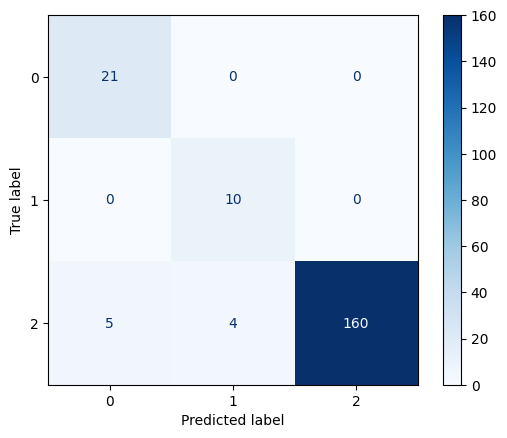

In [15]:
y_pred_test = train_pipe.predict(X_test)
print(classification_report(y_test_processed, y_pred_test, target_names=['N','P','Y']))
ConfusionMatrixDisplay.from_estimator(train_pipe, X_test, y_test_processed,cmap='Blues')
plt.savefig('../outputs/classification/lr_confusion_matrix.png', dpi=150, bbox_inches='tight')

### DecisionTree Classifier

Decision trees are interpretable ,we can literally follow the if-then logic from root to leaf.  
The trade-off is high variance: trees tend to overfit unless you constrain their depth.  
We test two versions: default (unconstrained) and with `max_depth` and `min_samples_split` controls.


In [16]:
clf = DecisionTreeClassifier( random_state=42)

train_pipe_dt = ImbPipeline(
    steps=[
        ('transformer', transformer),
        ('sm', SMOTE(sampling_strategy='not majority', random_state=42)),
        ('clf', clf)
    ], 
    
)

train_pipe_dt.fit(X_train, y_train_processed)

,steps,"[('transformer', ...), ('sm', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The giv

              precision    recall  f1-score   support

           N       1.00      1.00      1.00        21
           P       1.00      0.80      0.89        10
           Y       0.99      1.00      0.99       169

    accuracy                           0.99       200
   macro avg       1.00      0.93      0.96       200
weighted avg       0.99      0.99      0.99       200



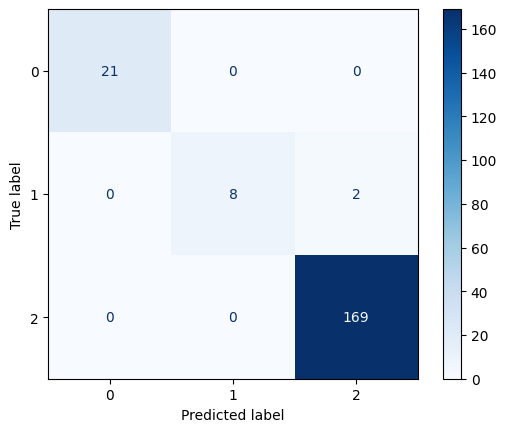

In [17]:
y_pred_test = train_pipe_dt.predict(X_test)
print(classification_report(y_test_processed, y_pred_test, target_names=['N','P','Y']))
ConfusionMatrixDisplay.from_estimator(train_pipe_dt, X_test, y_test_processed,cmap='Blues')
plt.savefig('../outputs/classification/dt_confusion_matrix_default.png', dpi=150, bbox_inches='tight')

In [18]:
clf_complex = DecisionTreeClassifier( random_state=42, max_depth=20, min_samples_split=8)

train_pipe_dt = ImbPipeline(
    steps=[
        ('transformer', transformer),
        ('smote', SMOTE(sampling_strategy='not majority', random_state=42)),
        ('clf', clf_complex)
    ]
)

train_pipe_dt.fit(X_train, y_train_processed)

,steps,"[('transformer', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The 

              precision    recall  f1-score   support

           N       1.00      1.00      1.00        21
           P       1.00      0.60      0.75        10
           Y       0.98      1.00      0.99       169

    accuracy                           0.98       200
   macro avg       0.99      0.87      0.91       200
weighted avg       0.98      0.98      0.98       200



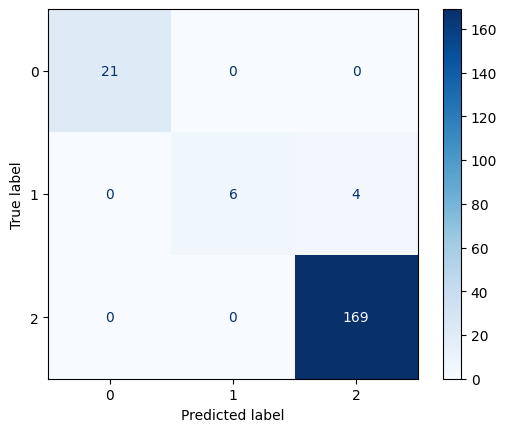

In [19]:
y_pred_test = train_pipe_dt.predict(X_test)
print(classification_report(y_test_processed, y_pred_test, target_names=['N','P','Y']))
ConfusionMatrixDisplay.from_estimator(train_pipe_dt, X_test, y_test_processed,cmap='Blues')
plt.savefig('../outputs/classification/dt_confusion_matrix.png', dpi=150, bbox_inches='tight')

### RandomForest Classifier

Random Forest is an ensemble of decision trees, where each tree is trained on a random subset of data and features.  
The *ensemble effect* dramatically reduces variance while maintaining the expressiveness of individual trees.  
It is popular for tabular medical data as it is robust, handles mixed feature types well, naturally provides feature importance.

In [20]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

rf_pipe = ImbPipeline(
    steps=[
        ('transformer', transformer),
        ('smote', SMOTE(sampling_strategy='not majority', random_state=42)),
        ('clf', rf)
    ]
)

rf_pipe.fit(X_train, y_train_processed)

,steps,"[('transformer', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The 

              precision    recall  f1-score   support

           N       0.95      1.00      0.98        21
           P       1.00      1.00      1.00        10
           Y       1.00      0.99      1.00       169

    accuracy                           0.99       200
   macro avg       0.98      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



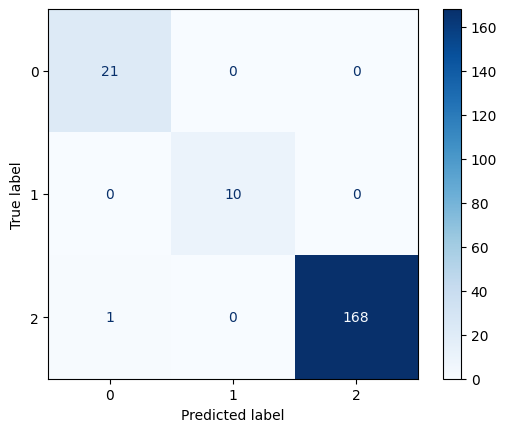

In [21]:
y_pred_test = rf_pipe.predict(X_test)
print(classification_report(y_test_processed, y_pred_test, target_names=['N','P','Y']))
ConfusionMatrixDisplay.from_estimator(rf_pipe, X_test, y_test_processed,cmap='Blues')
plt.savefig('../outputs/classification/rf_confusion_matrix.png', dpi=150, bbox_inches='tight')

### XGBoost Classifier


XGBoost (Extreme Gradient Boosting) builds trees *sequentially*, each one correcting the errors of the previous.  
It's generally the highest performer on tabular datasets.  
Unlike Random Forest (parallel trees), XGBoost is sensitive to hyperparameters , which is why we tune it with Optuna in the next section.


XGBoost Performance:
              precision    recall  f1-score   support

           N       1.00      0.95      0.98        21
           P       1.00      1.00      1.00        10
           Y       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200



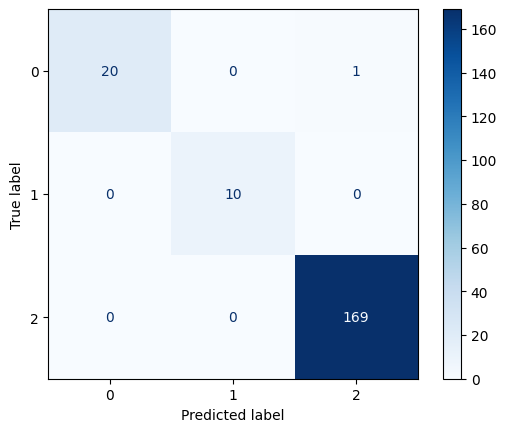

In [28]:
xgb_clf = XGBClassifier(eval_metric='mlogloss', random_state=42, )

# Build pipeline
xgb_pipe = ImbPipeline([
    ('transformer', transformer),
    ('smote', SMOTE(sampling_strategy='not majority', random_state=42)),
    ('xgb', xgb_clf)
])

# Train
xgb_pipe.fit(X_train, y_train_processed)

# Validate
y_test_pred = xgb_pipe.predict(X_test)

print("XGBoost Performance:")
print(classification_report(y_test_processed, y_test_pred, target_names=['N','P','Y']))
ConfusionMatrixDisplay.from_estimator(xgb_pipe, X_test, y_test_processed,cmap='Blues')
plt.savefig('../outputs/classification/xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')

## Hyperparameter Tuning with Optuna <a id='5'></a>

Instead of manually trying different parameter combinations (grid search), we use **Optuna** which is a Bayesian optimization framework.  
Optuna is smarter than grid search, it learns which parameter regions are promising and focuses trials there.

We search across 4 model types simultaneously (LR, RF, GBM, XGB) and let Optuna pick the best combination.  
80 trials should be enough to find a near-optimal configuration for this dataset size.


In [31]:
def objective(trial):
    # Choose the model 
    classifier_name = trial.suggest_categorical('classifier', ['RandomForestClassifier', 'GradientBoostingClassifier', 'XGBClassifier', 'LogisticRegression'])
    
    if classifier_name == 'RandomForestClassifier':
        # Comprehensive RandomForest parameters
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        max_depth = trial.suggest_int('max_depth', 3, 30)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])
        
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            bootstrap=bootstrap,
            random_state=42
        )
    
    elif classifier_name == 'GradientBoostingClassifier':
        # Comprehensive GradientBoosting parameters
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        subsample = trial.suggest_float('subsample', 0.6, 1.0)
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        
        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            subsample=subsample,
            max_features=max_features,
            random_state=42
        )
    
    elif classifier_name == 'XGBClassifier':
        # Comprehensive XGBoost parameters
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
        subsample = trial.suggest_float('subsample', 0.6, 1.0)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
        reg_alpha = trial.suggest_float('reg_alpha', 0.0, 10.0)
        reg_lambda = trial.suggest_float('reg_lambda', 0.0, 10.0)
        
        model = XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_child_weight=min_child_weight,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            eval_metric='mlogloss',
            random_state=42
        )
    
    elif classifier_name == 'LogisticRegression':

        C = trial.suggest_float('C', 0.001, 100.0, log=True)
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
        class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

        model = LogisticRegression(
            C=C,
            l1_ratio=l1_ratio,     # controls regularization mix
            solver='saga',         # required for elasticnet
            class_weight=class_weight,
            max_iter=5000,
            random_state=42
        )
        
    pipe = ImbPipeline(
        steps=[
            ('transformer', transformer ),
            ('smote', SMOTE(sampling_strategy='not majority', random_state=42)),
            ('classifier', model)
        ]
    )
    
    # Evaluate model performance
    score = cross_val_score(pipe, X_train, y_train_processed, cv=5, scoring='f1_macro').mean()
    return score


In [32]:
# Creating a study 
study = optuna.create_study(direction='maximize')
# Optimize the objective function
study.optimize(objective, n_trials=80)

[I 2026-03-02 10:03:26,848] A new study created in memory with name: no-name-8344943c-7b1c-4a6a-b7e8-893fb5f70ce4
[I 2026-03-02 10:03:29,564] Trial 0 finished with value: 0.9317862019040255 and parameters: {'classifier': 'RandomForestClassifier', 'n_estimators': 238, 'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.9317862019040255.
[I 2026-03-02 10:03:33,574] Trial 1 finished with value: 0.9580971807820022 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 338, 'learning_rate': 0.12096585099695219, 'max_depth': 14, 'min_child_weight': 4, 'subsample': 0.7291918507578846, 'colsample_bytree': 0.9367856267048535, 'reg_alpha': 0.48068708661293313, 'reg_lambda': 6.827818056331948}. Best is trial 1 with value: 0.9580971807820022.
[I 2026-03-02 10:03:33,821] Trial 2 finished with value: 0.7913100092680804 and parameters: {'classifier': 'LogisticRegression', 'C': 0.46462755171421377, 'l1_ratio

In [33]:
vis.plot_optimization_history(study)

In [34]:
print(f"Best Trial Score: {study.best_value}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")  


Best Trial Score: 0.968580880089231
Best Hyperparameters:
  classifier: XGBClassifier
  n_estimators: 277
  learning_rate: 0.16840800550956161
  max_depth: 4
  min_child_weight: 5
  subsample: 0.913560680823481
  colsample_bytree: 0.9303161767747471
  reg_alpha: 0.9176460898909897
  reg_lambda: 4.8058168270884405


              precision    recall  f1-score   support

           N       1.00      0.95      0.98        21
           P       1.00      1.00      1.00        10
           Y       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200



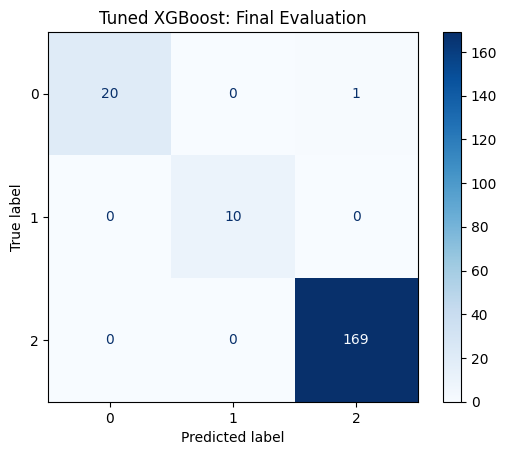

In [35]:
best_params = study.best_params

best_xgb = XGBClassifier(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    min_child_weight=best_params['min_child_weight'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    eval_metric='mlogloss',
    random_state=42
)

best_pipe = ImbPipeline([
    ('transformer', transformer),
    ('smote', SMOTE(sampling_strategy='not majority', random_state=42)),
    ('xgb', best_xgb)
])

best_pipe.fit(X_train, y_train_processed)
y_pred_best = best_pipe.predict(X_test)
print(classification_report(y_test_processed, y_pred_best, target_names=['N','P','Y']))
ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test_processed, cmap='Blues')
plt.title('Tuned XGBoost: Final Evaluation')
plt.show()

## Error Analysis

Lets see what the error/wrong prediction tells us

In [36]:
y_pred_best = best_pipe.predict(X_test)
errors_idx = y_pred_best != y_test_processed

X_test_reset = X_test.reset_index(drop=True)
errors = X_test_reset[errors_idx].copy()
errors['True'] = le.inverse_transform(y_test_processed[errors_idx])
errors['Predicted'] = le.inverse_transform(y_pred_best[errors_idx])

print(f"Total misclassified: {errors_idx.sum()} / {len(y_test_processed)}")
print(f"\nError breakdown:")
print(pd.crosstab(errors['True'], errors['Predicted']))
print(f"\nMisclassified samples:")
print(errors[['True','Predicted','HbA1c','BMI','AGE']].to_string())

Total misclassified: 1 / 200

Error breakdown:
Predicted  Y
True        
N          1

Misclassified samples:
   True Predicted  HbA1c   BMI  AGE
57    N         Y    4.2  24.0   59


The model misclassified 1 out of 200 samples (0.5% error rate), indicating very strong overall performance.

The single error was a false positive (True = N, Predicted = Y). The misclassified sample had HbA1c = 4.2, BMI = 24.0, and Age = 59.

In [37]:
# Are misclassified samples borderline cases?
print("HbA1c stats of misclassified vs correct:")
X_test_reset['correct'] = ~errors_idx
X_test_reset['correct'].map({True:'Correct', False:'Wrong'})
print(X_test_reset.groupby(~errors_idx)['HbA1c'].describe().round(2))

HbA1c stats of misclassified vs correct:
       count  mean   std  min   25%  50%  75%   max
False    1.0  4.20   NaN  4.2  4.20  4.2  4.2   4.2
True   199.0  8.22  2.26  4.2  6.75  8.0  9.8  12.4


The HbA1c value (4.2) is at the minimum of the dataset and well below the mean HbA1c of correctly classified samples (8.22). This suggests the error was not due to a borderline HbA1c value, but possibly due to interactions between other features in the model.

Overall, the classifier demonstrates high robustness with only one misclassification.

### Classification Summary

In [41]:
from sklearn.metrics import f1_score

models = {
    'Logistic Regression': train_pipe,
    'Decision Tree': train_pipe_dt,
    'Random Forest': rf_pipe,
    'XGBoost (baseline)': xgb_pipe,
    'XGBoost (tuned)': best_pipe,
}

results = []
for name, pipe in models.items():
    y_pred = pipe.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': round((y_pred == y_test_processed).mean(), 4),
        'F1 Macro': round(f1_score(y_test_processed, y_pred, average='macro'), 4),
        'F1 Weighted': round(f1_score(y_test_processed, y_pred, average='weighted'), 4),
    })

pd.DataFrame(results).sort_values('F1 Macro', ascending=False)

,Model,Accuracy,F1 Macro,F1 Weighted
2,Random Forest,0.995,0.9913,0.9951
3,XGBoost (baseline),0.995,0.9909,0.9949
4,XGBoost (tuned),0.995,0.9909,0.9949
1,Decision Tree,0.980,0.9128,0.9776
0,Logistic Regression,0.955,0.8999,0.9574


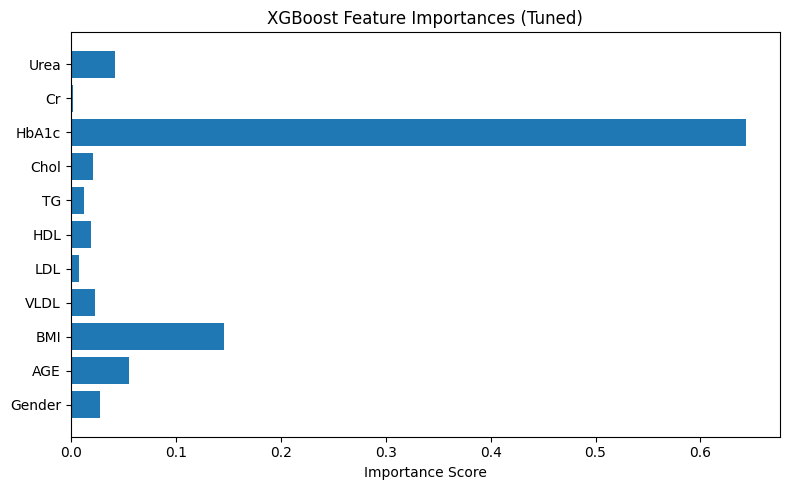

In [39]:
feature_names = num_cols + ['Gender']
importances = best_pipe.named_steps['xgb'].feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.title('XGBoost Feature Importances (Tuned)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


| Model | Key Strength | Key Weakness |
|---|---|---|
| Logistic Regression | Interpretable, fast | Assumes linear boundaries |
| Decision Tree | Transparent rules | Overfits without depth control |
| Random Forest | Robust, good feature importance | Slow to train, less interpretable |
| XGBoost | Generally best performance | Sensitive to hyperparameters |
| Tuned (Optuna) | Best of the above | Takes time to run |



Extremely high scores (99%+) are probably inflated by patient data overlapping in the train and test sets. The dataset contains 39 patients with multiple visits. In production, a group-based split by patient ID would give a more honest evaluation of generalization to genuinely new patients.